# Week 5 – Anomaly Detection

Objective:
- Detect anomalous network traffic using unsupervised learning
- Compare different anomaly detection techniques
- Analyze how well anomalies align with attack patterns

In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [2]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

# Binary classification
df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

In [3]:
preprocessor = joblib.load("models/preprocessor.pkl")

X_processed = preprocessor.transform(X)

print("Processed Shape:", X_processed.shape)

Processed Shape: (125973, 121)


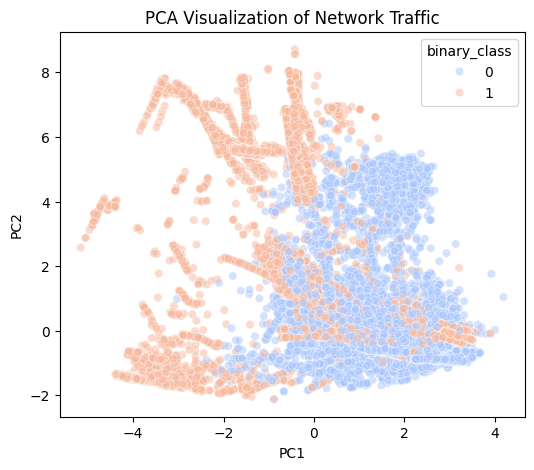

In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette='coolwarm',
    alpha=0.5
)

plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_processed)

# Distance from nearest centroid
distances = kmeans.transform(X_processed).min(axis=1)

threshold = np.percentile(distances, 97)

anomalies_kmeans = distances > threshold

print("K-Means Anomalies Detected:", anomalies_kmeans.sum())

K-Means Anomalies Detected: 3780


In [6]:
iso = IsolationForest(contamination=0.03, random_state=42)

iso_pred = iso.fit_predict(X_processed)

anomalies_iso = (iso_pred == -1)

print("Isolation Forest Anomalies Detected:", anomalies_iso.sum())

Isolation Forest Anomalies Detected: 3780


In [7]:
sample_size = 5000
X_sample = X_processed[:sample_size]

lof = LocalOutlierFactor(n_neighbors=20)

lof_pred = lof.fit_predict(X_sample)

print("LOF Anomalies Detected (Sample):", (lof_pred == -1).sum())

LOF Anomalies Detected (Sample): 1011


In [8]:
svm = OneClassSVM(nu=0.05)

svm.fit(X_sample)

svm_pred = svm.predict(X_sample)

print("One-Class SVM Anomalies Detected (Sample):", (svm_pred == -1).sum())

One-Class SVM Anomalies Detected (Sample): 252


In [9]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "Isolation Forest", "LOF", "One-Class SVM"],
    "Anomalies Detected": [
        anomalies_kmeans.sum(),
        anomalies_iso.sum(),
        (lof_pred == -1).sum(),
        (svm_pred == -1).sum()
    ]
})

comparison

,Method,Anomalies Detected
0,K-Means,3780
1,Isolation Forest,3780
2,LOF,1011
3,One-Class SVM,252


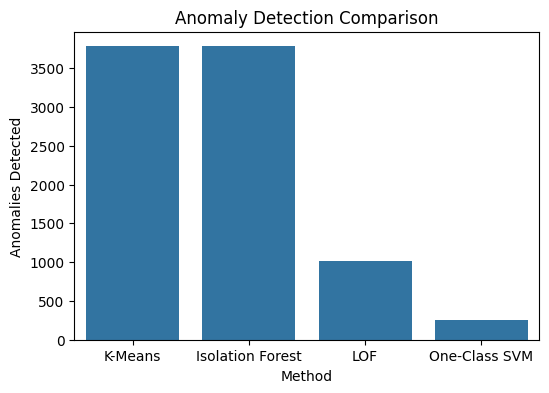

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Method",
    y="Anomalies Detected",
    data=comparison
)

plt.title("Anomaly Detection Comparison")

plt.show()

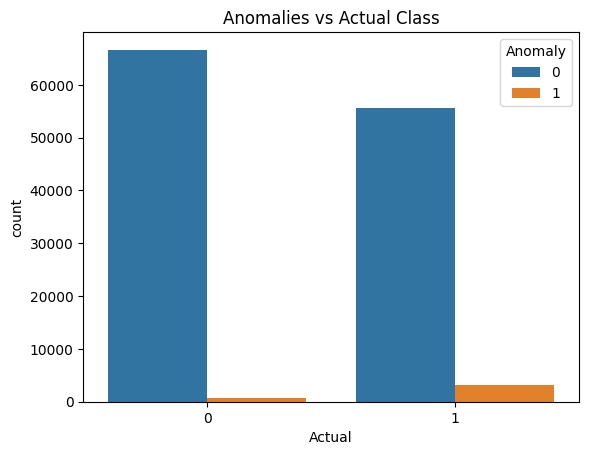

In [12]:
anomaly_df = pd.DataFrame({
    "Actual": y,
    "Anomaly": anomalies_iso.astype(int)
})

sns.countplot(x="Actual", hue="Anomaly", data=anomaly_df)

plt.title("Anomalies vs Actual Class")
plt.show()

## Observation

- Isolation Forest effectively detects global anomalies in network traffic.
- K-Means identifies anomalies based on distance from cluster centers.
- LOF captures local density-based anomalies but is computationally expensive.
- One-Class SVM learns a boundary around normal traffic but is sensitive to parameter choice.
- PCA visualization shows partial separation between normal and anomalous data.

## Conclusion

- Multiple anomaly detection techniques were applied to identify unusual network behavior.
- Isolation Forest provided the most consistent results for large-scale anomaly detection.
- K-Means helped identify anomalies based on cluster distance.
- LOF and One-Class SVM provided additional perspectives on anomaly detection.
- These methods complement supervised learning by detecting unknown or unseen attack patterns.